# Design a Tmaze with 4 observations. It is the simplest formulation of the problem for better efficiency of model training and clarity. 
### Observation = [Cheese, Shock, Right(Cue), Left(Cue)]
### Action = [ Right, Left, Cue ] 
## We start with the classical TRAP scenario where the mouse cant leave once it goes right or left. We will then work in a scenario where this does not happen. I will claim that Right and Left actions will also become informative.



# The main hypothesis is that Empowerment increases after taking an action that maximizes information gain

## There are two timesteps. The simulation starts with an action $a_1$, followed by an observation $o_2$. The second timestep has action $a_2$ and observation $o_3$

## 1. Compute Empowerment at $t_1$ as $\underset{p(a_1)}{max} \ I (a_1, o_2)$

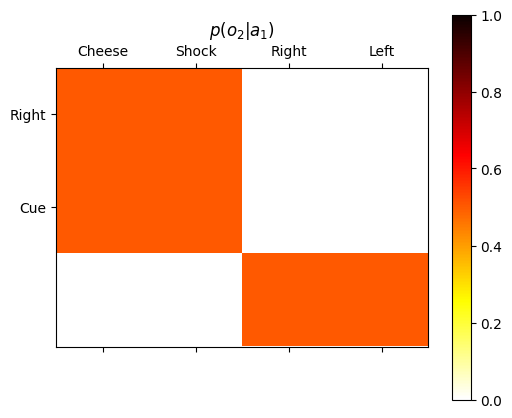

In [ ]:
# Define conditional p(o_2 | a_1)
import numpy as np
import src.utils as u

o_n = 4  # Example number of outcomes for o_2
oLabels = ["Cheese", "Shock", "Right", "Left"]

a1_n = 3  # Example number of actions for a_1
a1Labels = ["Right", "Left", "Cue"]

p_o2_given_a1 = np.array([
    [ 0.5, 0.5, 0, 0],
    [ 0.5, 0.5, 0, 0],
    [ 0, 0, 0.5, 0.5],
])


# p_o2_given_a1 = np.array([
#     #[ 0.5, 0.5, 0, 0],
#     [ 0.5, 0.5, 0, 0],
#     [ 0, 0, 0.5, 0.5],
# ])

u.plot_distribution(p_o2_given_a1, title="$p(o_2 | a_1)$", x_labels=oLabels, y_labels=["Right", "Cue"])

In [ ]:
import torch as t
p_a1, empowerment_a1o2 = u.compute_empowerment(t.tensor(p_o2_given_a1), base=2)  # specify base=2 
print("Empowerment t_1 :", np.round(empowerment_a1o2, 4), "bits ")
print("Optimal p(a_1):", p_a1)

Converged in 0 iterations.
H(O) = 2.0000, H(O|A) = 1.0000
Empowerment t_1 : 1.0 bits 
Optimal p(a_1): [0.25 0.25 0.5 ]


#### Empowerment is ~0.92 bits at $t_1$. Right and Left are identical actions in the sense that the expected observations are the same. This is why the mouse is not maximally empowered. These actions are in fact different, just that the mouse does not know any better right now. 

## 2. Compute information gain for $a_1$ as $I(s_2;o_2|a_1)$ = $H[p(o_2|a_1)]$ - $E_{p(s_2|a_1)}H[p(o_2|s_2)]$
### We already have $p(o_2|a_1)$ so we just need the other two distributions that depend on hidden states. We will initially stipulate them and then learn them with Tensor Nets

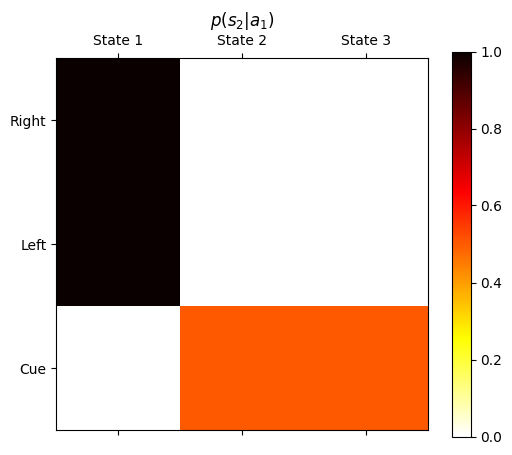

In [ ]:
p_s2_given_a1 = np.array([
    [ 1, 0, 0],
    [ 1, 0, 0],
    [ 0, 0.5, 0.5],
])  
u.plot_distribution(p_s2_given_a1, title="$p(s_2 | a_1)$", x_labels=["State 1", "State 2", "State 3"], y_labels=a1Labels)

### We assume the hidden state space to be mapped to actions as such. We will later attempt to structure learn these distributions without prior knowledge with Tensor Nets.
### Actions RIght and Left lead to the same observations and so are mapped to the same hidden state (only because the mouse is trapped and cant compare the observation to the one at the cue).
### The Cue action leads to an uncertainty of two states because both observations are mappable to the cheese or shock in the next time step

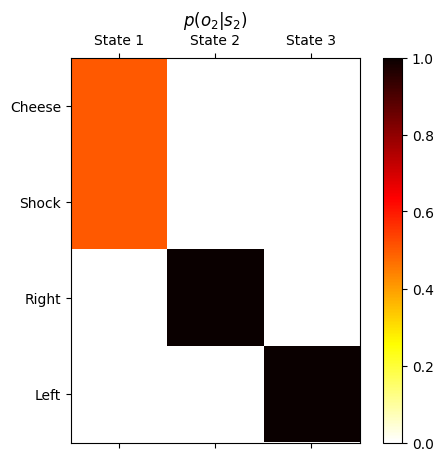

In [ ]:
p_o2_given_s2 = np.array([
    [ 0.5, 0, 0],
    [ 0.5, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1],
]) .T
u.plot_distribution(p_o2_given_s2.T, title="$p(o_2 | s_2)$", x_labels=["State 1", "State 2", "State 3"], y_labels=oLabels)

### We now show that this choice of  hidden states are correct and recover our action to observation distribution

Recovered p(o_2|a_1) shape: (3, 4)
Original p(o_2|a_1) shape: (3, 4)
Are they equal? True


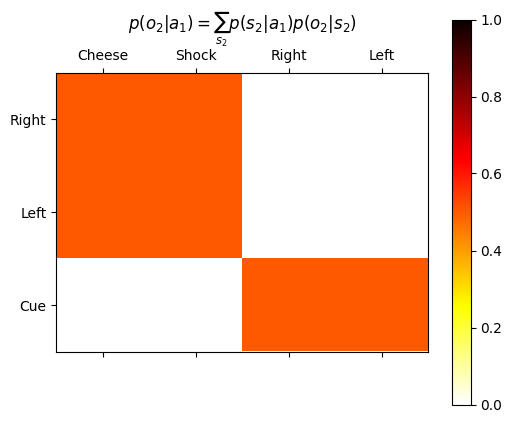

In [ ]:
# Marginalize over hidden states to recover p(o_2 | a_1)
# p(o_2 | a_1) = sum_s2 p(s_2 | a_1) * p(o_2 | s_2)
recovered_p_o2_given_a1 = p_s2_given_a1 @ p_o2_given_s2
print("Recovered p(o_2|a_1) shape:", recovered_p_o2_given_a1.shape)
print("Original p(o_2|a_1) shape:", p_o2_given_a1.shape)
print("Are they equal?", np.allclose(recovered_p_o2_given_a1, p_o2_given_a1))
u.plot_distribution(recovered_p_o2_given_a1, title="$p(o_2 | a_1) = \\sum_{s_2} p(s_2 | a_1) p(o_2 | s_2)$", x_labels=oLabels, y_labels=a1Labels)

### Now that we have the necessary distributions we can compute the information gain term for each action.
### $I(s_2;o_2|a_1)$ = $H[p(o_2|a_1)]$ - $E_{p(s_2|a_1)}H[p(o_2|s_2)]$

In [ ]:
def mi(o_given_a, s_given_a, o_given_s):
    H_o_given_a = u.shannon_entropy(o_given_a,axis=1)
    
    H_o_given_s = u.shannon_entropy(o_given_s,axis=1)
    Expected_H_o_given_s = np.sum(s_given_a * H_o_given_s, axis=1)
    
    return H_o_given_a - Expected_H_o_given_s
    
infogain = mi(p_o2_given_a1, p_s2_given_a1, p_o2_given_s2)
print("Information Gain:", infogain)

Information Gain: [0. 0. 1.]


### We have proven that Actions Left and Right are expected to gain 0 bits of information whereas the Cue action will gain 1 bit. 

## 3. Compute Empowerment at $t_2$ for each $a_1$

#### 3.1 For $a_1$ = Right and $o_2$ = Cheese:
#### (works analogously if $a_1$ = Left or $o_2$ = Shock)

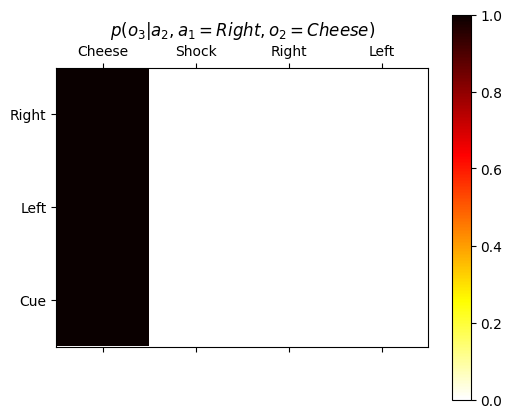

In [ ]:
# Define conditional p(o_2 | a_2, a_1=Right, o_2=Cheese )

p_o3_given_a2_right = np.array([
    [1, 0, 0, 0],
    [1, 0, 0, 0],
    [ 1, 0, 0, 0],
])
u.plot_distribution(p_o3_given_a2_right, title="$p(o_3 | a_2, a_1 = Right, o_2 = Cheese)$", x_labels=oLabels, y_labels=a1Labels)

In [ ]:
p_a2, empowerment_right = u.compute_empowerment(t.tensor(p_o3_given_a2_right), base=2)  # specify base=2 
print("Empowerment t_2 :", np.round(empowerment_right, 4), "bits ")
print("Optimal p(a_2):", p_a2)

Converged in 0 iterations.
H(O) = -0.0000, H(O|A) = -0.0000
Empowerment t_2 : 0.0 bits 
Optimal p(a_2): [0.33333333 0.33333333 0.33333333]


#### The mouse has 0 empowerment after entering a trap. all its actions are redundant.

### 3.2 $a_1$ = Cue and $o_2$ = Right:
### (analogous for $o_2$ = Left)

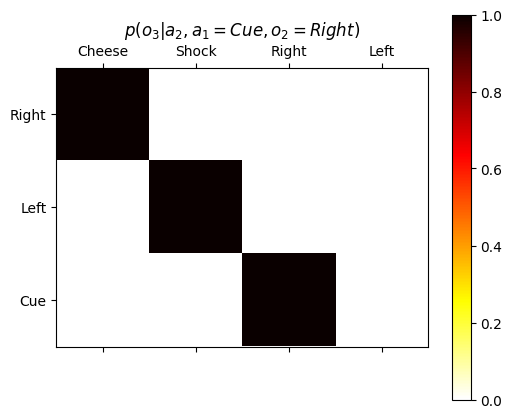

In [ ]:
# Define conditional p(o_3 | a_2, a_1=Cue, o_2 = Right)

p_o3_given_a2_cue = np.array([
    [ 1, 0, 0, 0],
    [ 0, 1, 0, 0],
    [ 0, 0, 1, 0],
])
u.plot_distribution(p_o3_given_a2_cue, title="$p(o_3 | a_2, a_1 = Cue, o_2 = Right)$", x_labels=oLabels, y_labels=a1Labels)

In [ ]:
_a1, empowerment_cue = u.compute_empowerment(t.tensor(p_o3_given_a2_cue), base=2)  # specify base=2 
print("Empowerment t_2 :", np.round(empowerment_cue, 4), "bits ")
print("Optimal p(a_2):", p_a1)

Converged in 0 iterations.
H(O) = 1.5850, H(O|A) = -0.0000
Empowerment t_2 : 1.585 bits 
Optimal p(a_2): [0.25 0.25 0.5 ]


#### Empowerment has increased from 1 to ~1.59 bits when going to the cue. This is because the redundant actions of Right and Left have been discriminated  . The mouse is even maximally empowered as each of its 3 actions is unique and non overlapping.

# NO TRAP SCENARIO

### We are going to repeat the measurements performed above for this alternative scenario to show that Right and Left become informative when these states are empowered enough. The reason why traps are uninformative is that information gain is the detection of correlation between two states. If one of those states is inaccesible (because the mouse is stuck at the other one) then it ceases to be informative. THe two states are Cheese/Shock and the Cue. If the mouse can only visit one, it cant see the correlation between them. If it can access both freely ( as we will show now) they are both informative

# The hypothesis here is that Right and Left actions are also informative when they are not traps. 

### This will also lead the mouse to become empowered when it takes them. It gains the same amount of information as going to the Cue, 1 bit. As it has reduced its uncertainty (entropy) over the Cheese and Shock states by 1 bit.

## 1. Compute Empowerment at $t_1$ as $\underset{p(a_1)}{max} \ I (a_1, o_2)$

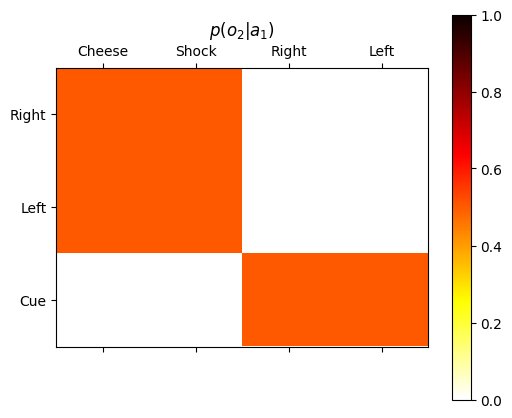

In [ ]:
# Define conditional p(o_2 | a_1)

p_o2_given_a1 = np.array([
    [ 0.5, 0.5, 0, 0],
    [ 0.5, 0.5, 0, 0],
    [ 0, 0, 0.5, 0.5],
])
u.plot_distribution(p_o2_given_a1, title="$p(o_2 | a_1)$", x_labels=oLabels, y_labels=a1Labels)

### Our action to observation mapping does not change in this scenario. The expected observations are the same. What changes are the hidden states and the accessible observations in the second time step

In [ ]:
import torch as t
p_a1, empowerment_a1o2 = u.compute_empowerment(t.tensor(p_o2_given_a1), base=2)  # specify base=2 
print("Empowerment t_1 :", np.round(empowerment_a1o2, 4), "bits ")
print("Optimal p(a_1):", p_a1)

Converged in 0 iterations.
H(O) = 2.0000, H(O|A) = 1.0000
Empowerment t_1 : 1.0 bits 
Optimal p(a_1): [0.25 0.25 0.5 ]


## 2. Compute information gain for $a_1$ as $I(s_2;o_2|a_1)$ = $H[p(o_2|a_1)]$ - $E_{p(s_2|a_1)}H[p(o_2|s_2)]$
### We already have $p(o_2|a_1)$ so we just need the other two distributions that depend on hidden states. We will initially stipulate them and then learn them with Tensor Nets

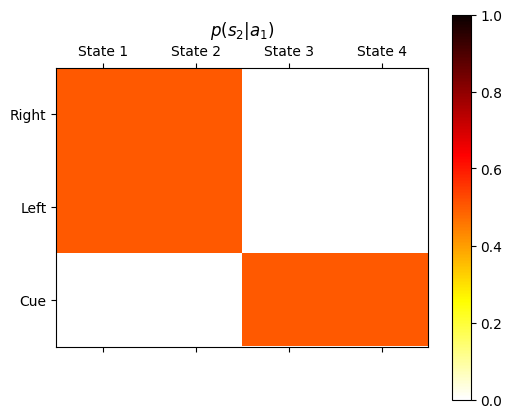

In [ ]:
p_s2_given_a1 = np.array([
    [ 0.5, 0.5, 0, 0],
    [ 0.5, 0.5, 0, 0],
    [ 0, 0, 0.5, 0.5],
])  
u.plot_distribution(p_s2_given_a1, title="$p(s_2 | a_1)$", x_labels=["State 1", "State 2", "State 3", "State 4"], y_labels=a1Labels)

### We assume the hidden state space to be mapped to actions as such. We will later attempt to structure learn these distributions without prior knowledge with Tensor Nets.
### The Cue action still leads to an uncertainty of two states. Actions Right and Left now will do so as well. If they would lead to traps, they become effectively the same action as one receives a cheese or shock with 50% chance and cant leave to see what the cue is. As this has changed, there are now two distinct states, one for cheese and one for shock. That is, not only is the observation uncertain but also the hidden state. As the mapping to the observations discriminates the two hidden states, the hidden state uncertainty can be reduced, and thus information gained.

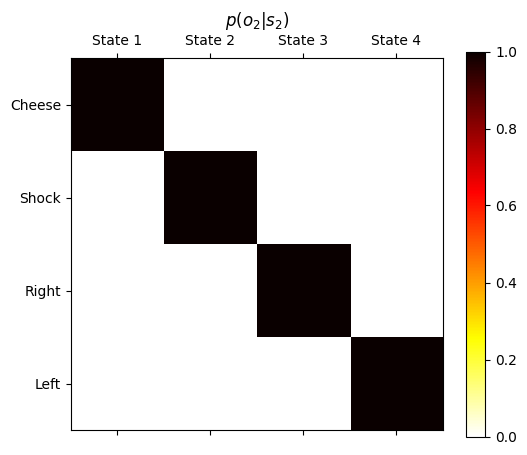

In [ ]:
p_o2_given_s2 = np.array([
    [ 1, 0, 0, 0],
    [ 0, 1, 0, 0],
    [ 0, 0, 1, 0],
    [ 0, 0, 0, 1],
]) .T
u.plot_distribution(p_o2_given_s2.T, title="$p(o_2 | s_2)$", x_labels=["State 1", "State 2", "State 3", "State 4"], y_labels=oLabels)

### The likelihood makes this very clear. If there is uncertainty over hidden states in $p(s_2|a_1)$ it is resolved once the observation is known. Thus, each action will gain 1 bit of information as we will now compute

### $I(s_2;o_2|a_1)$ = $H[p(o_2|a_1)]$ - $E_{p(s_2|a_1)}H[p(o_2|s_2)]$

In [ ]:
def mi(o_given_a, s_given_a, o_given_s):
    H_o_given_a = u.shannon_entropy(o_given_a,axis=1)
    
    H_o_given_s = u.shannon_entropy(o_given_s,axis=1)
    Expected_H_o_given_s = np.sum(s_given_a * H_o_given_s, axis=1)
    
    return H_o_given_a - Expected_H_o_given_s
    
infogain = mi(p_o2_given_a1, p_s2_given_a1, p_o2_given_s2)
print("Information Gain:", infogain)

Information Gain: [1. 1. 1.]


### Short check that these beliefs are valid

Are they equal? True


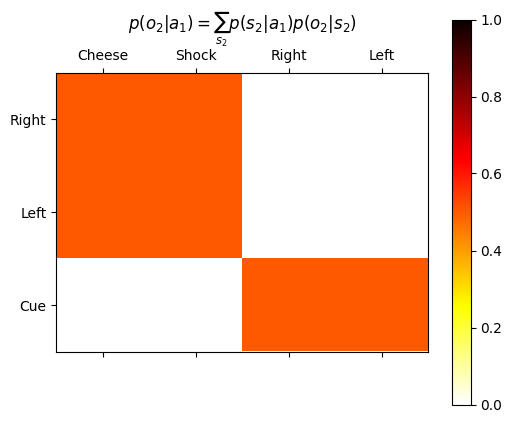

In [ ]:
# Marginalize over hidden states to recover p(o_2 | a_1)
# p(o_2 | a_1) = sum_s2 p(s_2 | a_1) * p(o_2 | s_2)
recovered_p_o2_given_a1 = p_s2_given_a1 @ p_o2_given_s2

print("Are they equal?", np.allclose(recovered_p_o2_given_a1, p_o2_given_a1))
u.plot_distribution(recovered_p_o2_given_a1, title="$p(o_2 | a_1) = \\sum_{s_2} p(s_2 | a_1) p(o_2 | s_2)$", x_labels=oLabels, y_labels=a1Labels)

## 3. Compute Empowerment at $t_2$ for $a_1$ = Right and $o_2$ = Cheese:
#### (works analogously if $a_1$ = Left or Cue or $o_2$ = Shock)

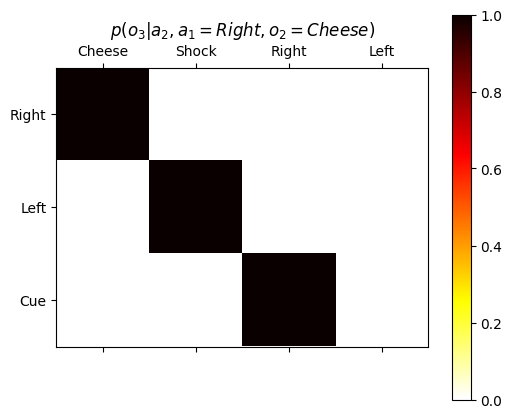

In [ ]:
# Define conditional p(o_3 | a_2, a_1=Right, o_2 = Cheese)

p_o3_given_a2_right = np.array([
    [ 1, 0, 0, 0],
    [ 0, 1, 0, 0],
    [ 0, 0, 1, 0],
])
u.plot_distribution(p_o3_given_a2_right, title="$p(o_3 | a_2, a_1 = Right, o_2 = Cheese)$", x_labels=oLabels, y_labels=a1Labels)

In [ ]:
import torch as t
p_a2, empowerment_a2o3 = u.compute_empowerment(t.tensor(p_o3_given_a2_right), base=2)  # specify base=2 
print("Empowerment t_2 :", np.round(empowerment_a2o3, 4), "bits ")
print("Optimal p(a_2):", p_a2)

Converged in 0 iterations.
H(O) = 1.5850, H(O|A) = -0.0000
Empowerment t_2 : 1.585 bits 
Optimal p(a_2): [0.33333333 0.33333333 0.33333333]


### Empowerment increases with every action as they are all informative. The mouse understands where the cheese is no matter if it goes to the Cue, or goes Right/Left to see a Cheese or see a shock (which means Cheese is in the other room). 

# Writing the beliefs down is easy enough. To support these claims I will train tensor nets to structure learn hidden states. Hopefully they will be identical to the ones stipulated here. 

In [ ]:
# Install minimal deps for this notebook run
%pip install -q -r requirements.txt 


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement apturl==0.5.2 (from versions: none)
ERROR: No matching distribution found for apturl==0.5.2


In [ ]:
import torch
import torch.nn.functional as F
from mpstwo.model.mpstwo import MPSTwo
from mpstwo.model.optimizers.sgd import SGD
from mpstwo.model.mpstwo_trainer import MPSTrainer
from mpstwo.data.datasets.dataset import Dataset
from mpstwo.data.datastructs.tensor_dict import TensorDict

# 1) Your trajectories: shape [num_traj, T] with ints
# Fill these with your trap-TMaze data (actions in {0,1,2}, obs in {0,1,2,3})
actions_np = ...  # e.g., np.array([[0,2], [1,2], ...])
obs_np     = ...  # e.g., np.array([[0,2], [1,3], ...])
T = actions_np.shape[1]

class TrajectoryDataset(Dataset):
    def __init__(self, actions, obs):
        super().__init__()
        self.actions = torch.tensor(actions, dtype=torch.long)
        self.obs = torch.tensor(obs, dtype=torch.long)
        self._len = self.actions.shape[0]
    def __len__(self): return self._len
    def _get_item(self, idx):
        return TensorDict({"action": self.actions[idx], "observation": self.obs[idx]})

train_ds = TrajectoryDataset(actions_np, obs_np)

# 2) Feature maps (multi-ary)
def feature_map_obs(x):  # [B,T] -> [B,T,4]
    return F.one_hot(x.long(), num_classes=4).float()
def feature_map_act(x):  # [B,T] -> [B,T,3]
    return F.one_hot(x.long(), num_classes=3).float()

# 3) Model and trainer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MPSTwo(
    physical_legs=T,
    feature_dim_obs=4,
    feature_dim_act=3,
    bond_dim=16,          # tune
    init_mode="random",
    init_std=0.1,
    device=device,
)

optimizer = SGD(model, lr=1e-2, two_site=True, cumulants=True)
trainer = MPSTrainer(
    model,
    train_ds,
    optimizer,
    feature_map_obs=feature_map_obs,
    feature_map_act=feature_map_act,
    batch_size=64,
    device=device,
    log_to="tensorboard",  # or "wandb" if configured
)

trainer.train(epochs=200)

ModuleNotFoundError: No module named 'gymnasium'